### Phase 1: Global Setup & Exploratory Data Analysis (EDA)
#### First, let's set up the environment and visualize the data to see exactly what the models will be learning from

In [3]:
import os
import glob
import soundfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization, Conv2D, 
                                     MaxPooling2D, Flatten, Input, Conv1D, 
                                     MaxPooling1D, Reshape, Attention, GlobalAveragePooling1D)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import AdamW

# RAVDESS Emotion Mapping
emotions = {
  '01':'neutral', '02':'calm', '03':'happy', '04':'sad',
  '05':'angry', '06':'fearful', '07':'disgust', '08':'surprised'
}
observed_emotions = ['calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

def perform_eda(sample_file):
    y, sr = librosa.load(sample_file, sr=None)
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(y, sr=sr, alpha=0.6)
    plt.title(f"Waveform: {os.path.basename(sample_file)}")
    
    plt.subplot(1, 2, 2)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title("Mel-Spectrogram")
    plt.tight_layout()
    plt.show()

### Phase 2: The Generalized Data Pipeline (Actor-Based Split)
#### Here, we extract the Actor ID from the filename (03-01-01-01-01-01-01.wav -> Actor 01). We allocate Actors 1-21 for Training, Actor 22 for Validation, and Actors 23-24 for Testing. Augmentation is strictly applied to the training set.

In [4]:
def add_noise(data):
    noise_amp = 0.005 * np.random.uniform() * np.amax(data)
    return data + noise_amp * np.random.normal(size=data.shape[0])

def pitch_shift(data, sample_rate):
    return librosa.effects.pitch_shift(y=data, sr=sample_rate, n_steps=0.7)

def get_features(X, sample_rate, extraction_type="1D", max_pad_len=200):
    mfccs = librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40)
    stft = np.abs(librosa.stft(X))
    chroma = librosa.feature.chroma_stft(S=stft, sr=sample_rate)
    mel = librosa.feature.melspectrogram(y=X, sr=sample_rate, n_mels=128)
    
    if extraction_type == "1D":
        mfccs_mean = np.mean(mfccs.T, axis=0)
        chroma_mean = np.mean(chroma.T, axis=0)
        mel_mean = np.mean(mel.T, axis=0)
        return np.hstack((mfccs_mean, chroma_mean, mel_mean))
        
    elif extraction_type == "2D":
        mfccs = (mfccs - np.mean(mfccs)) / (np.std(mfccs) + 1e-8)
        chroma = (chroma - np.mean(chroma)) / (np.std(chroma) + 1e-8)
        mel_db = librosa.power_to_db(mel, ref=np.max) 
        mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-8)

        if mfccs.shape[1] > max_pad_len:
            mfccs = mfccs[:, :max_pad_len]
            chroma = chroma[:, :max_pad_len]
            mel_db = mel_db[:, :max_pad_len]
        else:
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(mfccs, pad_width=((0, 0), (0, pad_width)), mode='constant')
            chroma = np.pad(chroma, pad_width=((0, 0), (0, pad_width)), mode='constant')
            mel_db = np.pad(mel_db, pad_width=((0, 0), (0, pad_width)), mode='constant')
        
        mfccs_padded = np.pad(mfccs, pad_width=((0, 128 - mfccs.shape[0]), (0, 0)), mode='constant')
        chroma_padded = np.pad(chroma, pad_width=((0, 128 - chroma.shape[0]), (0, 0)), mode='constant')
        features = np.stack((mfccs_padded, chroma_padded, mel_db), axis=-1)
        return features

def load_data_by_actor(extraction_type="1D"):
    X_train, y_train, X_val, y_val, X_test, y_test = [], [], [], [], [], []
    kaggle_path = "/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-song-audio/Actor_*/*.wav"
    file_list = glob.glob(kaggle_path)
    
    for file in tqdm(file_list, desc=f"Extracting {extraction_type} Features", unit="file"):
        file_name = os.path.basename(file)
        emotion = emotions[file_name.split("-")[2]]
        actor_id = int(file_name.split("-")[6].split(".")[0]) 
        
        if emotion not in observed_emotions:
            continue
            
        with soundfile.SoundFile(file) as sound_file:
            X = sound_file.read(dtype="float32")
            sample_rate = sound_file.samplerate
            if X.ndim > 1: X = np.mean(X, axis=1) 
            
            base_feat = get_features(X, sample_rate, extraction_type)

            # Creating the dataset or dividing the dataset
            if actor_id <= 21: 
                X_train.append(base_feat); y_train.append(emotion)
                X_train.append(get_features(add_noise(X), sample_rate, extraction_type)); y_train.append(emotion)
                X_train.append(get_features(pitch_shift(X, sample_rate), sample_rate, extraction_type)); y_train.append(emotion)
            elif actor_id == 22: 
                X_val.append(base_feat); y_val.append(emotion)
            else: 
                X_test.append(base_feat); y_test.append(emotion)

    encoder = LabelEncoder()
    y_train_enc = encoder.fit_transform(y_train)
    y_val_enc = encoder.transform(y_val)
    y_test_enc = encoder.transform(y_test)
    
    X_train, X_val, X_test = np.array(X_train), np.array(X_val), np.array(X_test)
    return (X_train, y_train_enc), (X_val, y_val_enc), (X_test, y_test_enc), encoder

# Load Both Datasets
print("--- Loading 1D Data ---")
(X_train_1d, y_train_1d), (X_val_1d, y_val_1d), (X_test_1d, y_test_1d), encoder = load_data_by_actor(extraction_type="1D")

print("\n--- Loading 2D Data ---")
(X_train_2d, y_train_2d), (X_val_2d, y_val_2d), (X_test_2d, y_test_2d), _ = load_data_by_actor(extraction_type="2D")

--- Loading 1D Data ---


Extracting 1D Features: 100%|██████████| 1012/1012 [04:23<00:00,  3.84file/s]



--- Loading 2D Data ---


Extracting 2D Features: 100%|██████████| 1012/1012 [04:01<00:00,  4.19file/s]


In [5]:
# Scale 1D features
scaler = StandardScaler()
X_train_1d = scaler.fit_transform(X_train_1d)
X_val_1d = scaler.transform(X_val_1d)
X_test_1d = scaler.transform(X_test_1d)

### Phase 3: The Models
#### Now we define and train both models using the clean splits.

### 1. The ANN Setup

In [6]:
# Shared Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

# ----------------------------------------------------
# 1. Train ANN
# ----------------------------------------------------
ann_model = Sequential([
    Dense(256, input_shape=(X_train_1d.shape[1],), activation='relu'),
    BatchNormalization(), Dropout(0.4),
    Dense(128, activation='relu'),
    BatchNormalization(), Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(), Dropout(0.3),
    Dense(len(observed_emotions), activation='softmax')
])
ann_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print("\nTraining ANN...")
ann_history = ann_model.fit(X_train_1d, y_train_1d, validation_data=(X_val_1d, y_val_1d), epochs=100, batch_size=32, verbose=0, callbacks=[early_stop, reduce_lr])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1777916915.767564      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



Training ANN...


I0000 00:00:1777916919.156689     172 service.cc:152] XLA service 0x6bef7f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777916919.156725     172 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777916919.609937     172 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777916922.044936     172 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


### 2. The CNN Setup

In [7]:
# ----------------------------------------------------
# 2. Train 2D CNN
# ----------------------------------------------------
cnn_model = Sequential([
    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(X_train_2d.shape[1], X_train_2d.shape[2], 3)),
    MaxPooling2D(pool_size=(2, 2)), BatchNormalization(),
    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)), BatchNormalization(),
    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)), BatchNormalization(),
    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)), BatchNormalization(),
    Flatten(), 
    Dense(128, activation='relu'), Dropout(0.4), 
    Dense(len(observed_emotions), activation='softmax')
])
cnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print("\nTraining 2D CNN...")
cnn_history = cnn_model.fit(X_train_2d, y_train_2d, validation_data=(X_val_2d, y_val_2d), epochs=100, batch_size=32, verbose=0, callbacks=[early_stop, reduce_lr])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training 2D CNN...


#### 3. Train 1D Advanced CNN

In [8]:
# ----------------------------------------------------
# 3. Train 1D Advanced CNN
# ----------------------------------------------------
inputs = Input(shape=(X_train_1d.shape[1],))
x = Reshape((X_train_1d.shape[1], 1))(inputs)
x = Conv1D(64, kernel_size=7, activation='relu', padding='same')(x)
x = BatchNormalization()(x); x = MaxPooling1D(pool_size=2)(x); x = Dropout(0.3)(x)
x = Conv1D(128, kernel_size=7, activation='relu', padding='same')(x)
x = BatchNormalization()(x); x = MaxPooling1D(pool_size=2)(x); x = Dropout(0.3)(x)
x = Conv1D(256, kernel_size=5, activation='relu', padding='same')(x)
x = BatchNormalization()(x); x = MaxPooling1D(pool_size=2)(x); x = Dropout(0.3)(x)

attention_out = Attention()([x, x])
x = GlobalAveragePooling1D()(attention_out)
x = Dense(128, activation='relu')(x); x = Dropout(0.4)(x)
outputs = Dense(len(observed_emotions), activation='softmax')(x)

cnn1d_model = Model(inputs=inputs, outputs=outputs)
cnn1d_model.compile(loss='sparse_categorical_crossentropy', optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4), metrics=['accuracy'])
print("\nTraining 1D CNN...")
cnn1d_history = cnn1d_model.fit(X_train_1d, y_train_1d, validation_data=(X_val_1d, y_val_1d), epochs=100, batch_size=16, verbose=0, callbacks=[early_stop, reduce_lr])


Training 1D CNN...


### Phase 4: The Showdown (Comparison)
#### Execute this block at the end of your notebook to generate a side-by-side graphical comparison and a detailed metrics table to formally determine the winner.

 THE MEGA ENSEMBLE RESULTS 
ANN Accuracy:    75.00%
2D CNN Accuracy: 77.50%
1D CNN Accuracy: 73.75%
 ENSEMBLE Accuracy: 80.00% 

Ensemble Classification Report:
              precision    recall  f1-score   support

       angry       0.70      1.00      0.82        16
        calm       0.93      0.81      0.87        16
     fearful       0.70      0.44      0.54        16
       happy       0.83      0.94      0.88        16
         sad       0.87      0.81      0.84        16

    accuracy                           0.80        80
   macro avg       0.80      0.80      0.79        80
weighted avg       0.80      0.80      0.79        80



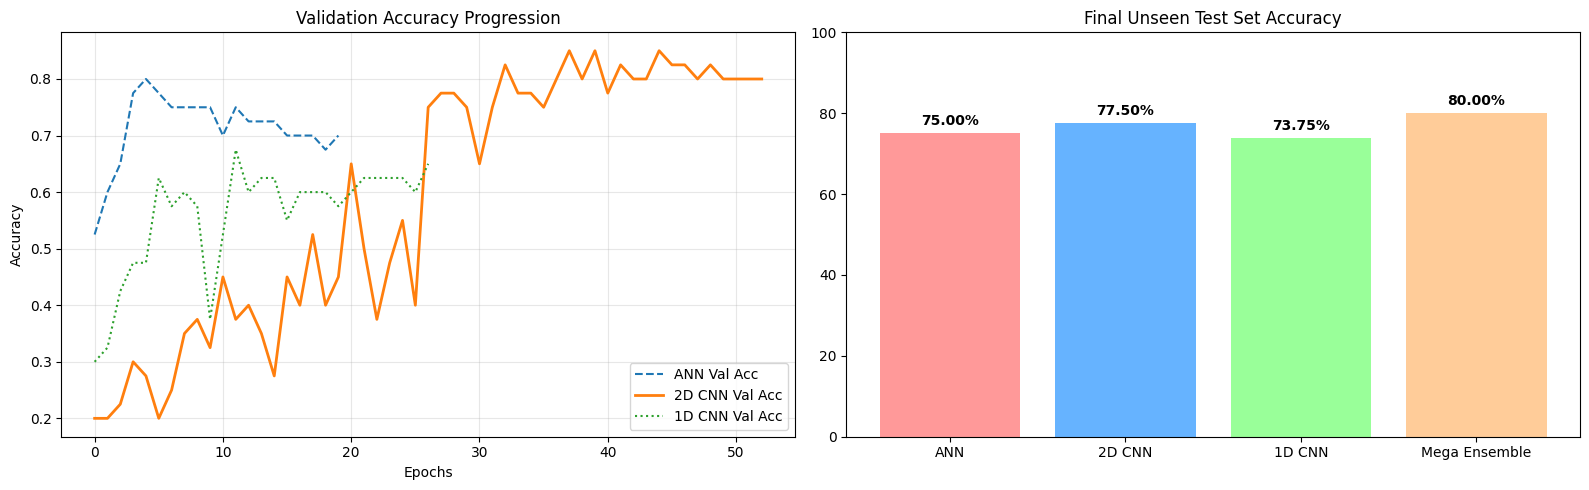

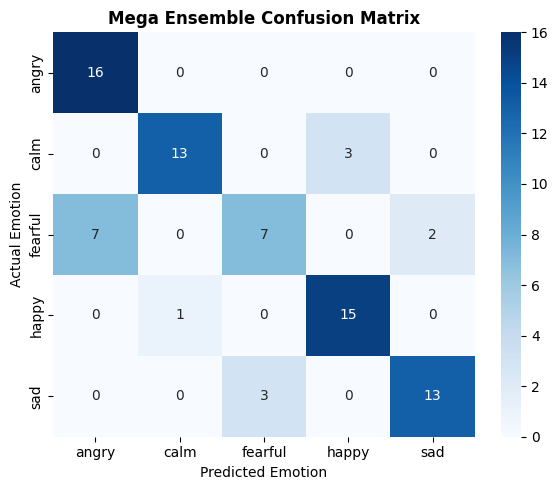

In [11]:
def plot_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title, fontweight='bold')
    plt.ylabel('Actual Emotion')
    plt.xlabel('Predicted Emotion')
    plt.tight_layout()
    plt.show()

# Get Raw Probabilities
ann_prob = ann_model.predict(X_test_1d, verbose=0)
cnn2d_prob = cnn_model.predict(X_test_2d, verbose=0)
cnn1d_prob = cnn1d_model.predict(X_test_1d, verbose=0)

# Calculate Accuracies
ann_acc = accuracy_score(y_test_1d, np.argmax(ann_prob, axis=1))
cnn2d_acc = accuracy_score(y_test_2d, np.argmax(cnn2d_prob, axis=1))
cnn1d_acc = accuracy_score(y_test_1d, np.argmax(cnn1d_prob, axis=1))

# THE MEGA ENSEMBLE (ANN + 2D CNN + 1D CNN)
mega_ensemble_prob = (ann_prob + cnn2d_prob + cnn1d_prob) / 3.0
ens_preds = np.argmax(mega_ensemble_prob, axis=1)
ens_acc = accuracy_score(y_test_1d, ens_preds)

print("="*50)
print(" THE MEGA ENSEMBLE RESULTS ")
print("="*50)
print(f"ANN Accuracy:    {ann_acc*100:.2f}%")
print(f"2D CNN Accuracy: {cnn2d_acc*100:.2f}%")
print(f"1D CNN Accuracy: {cnn1d_acc*100:.2f}%")
print(f" ENSEMBLE Accuracy: {ens_acc*100:.2f}% ")
print("\nEnsemble Classification Report:")
print(classification_report(y_test_1d, ens_preds, target_names=encoder.classes_))

# Plot Final Dashboard
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(ann_history.history['val_accuracy'], label='ANN Val Acc', linestyle='--')
axes[0].plot(cnn_history.history['val_accuracy'], label='2D CNN Val Acc', linewidth=2)
axes[0].plot(cnn1d_history.history['val_accuracy'], label='1D CNN Val Acc', linestyle=':')
axes[0].set_title('Validation Accuracy Progression')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

models = ['ANN', '2D CNN', '1D CNN', 'Mega Ensemble']
scores = [ann_acc * 100, cnn2d_acc * 100, cnn1d_acc * 100, ens_acc * 100]
axes[1].bar(models, scores, color=['#ff9999','#66b3ff', '#99ff99', '#ffcc99'])
axes[1].set_title('Final Unseen Test Set Accuracy')
axes[1].set_ylim(0, 100)
for i, v in enumerate(scores):
    axes[1].text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Plot Final Confusion Matrix
plot_confusion_matrix(y_test_1d, ens_preds, encoder.classes_, "Mega Ensemble Confusion Matrix")

In [13]:
# ============================================================
# Phase 5: ML Experiment Tracking with MLflow
# ============================================================

import subprocess
subprocess.run(["pip", "install", "mlflow", "-q"], check=True)

import mlflow
import mlflow.tensorflow
import mlflow.sklearn
import tempfile
import json
import os
import pickle
from sklearn.metrics import classification_report

# ----------------------------------------------------------
# Configure the MLflow experiment
# ----------------------------------------------------------
EXPERIMENT_NAME = "Emotion_Recognition_Audio"
mlflow.set_tracking_uri("mlruns")          # Local folder; swap with a remote URI if needed
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow experiment set to: '{EXPERIMENT_NAME}'")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")


# ----------------------------------------------------------
# Helper: log a Keras training history as metrics per epoch
# ----------------------------------------------------------
def log_history(history, prefix=""):
    """Log each epoch's metrics so the MLflow UI shows learning curves."""
    for metric, values in history.history.items():
        for epoch, value in enumerate(values):
            mlflow.log_metric(f"{prefix}{metric}", value, step=epoch)


# ----------------------------------------------------------
# Helper: compute and log a full classification report
# ----------------------------------------------------------
def log_classification_report(y_true, y_pred, class_names, run_name):
    """Save classification report as a JSON artifact."""
    report = classification_report(y_true, y_pred,
                                   target_names=class_names,
                                   output_dict=True)
    tmp_path = os.path.join(tempfile.mkdtemp(), f"{run_name}_classification_report.json")
    with open(tmp_path, "w") as f:
        json.dump(report, f, indent=2)
    mlflow.log_artifact(tmp_path, artifact_path="reports")
    return report


# ===========================================================
# Run 1 — ANN
# ===========================================================
print("\n[1/4] Logging ANN run...")
with mlflow.start_run(run_name="ANN"):
    mlflow.log_params({
        "model_type":          "ANN",
        "feature_type":        "1D (MFCC + Chroma + Mel mean)",
        "input_shape":         X_train_1d.shape[1],
        "layers":              "256 -> 128 -> 64 -> 7",
        "dropout":             "0.4 / 0.3 / 0.3",
        "batch_norm":          True,
        "optimizer":           "adam",
        "loss":                "sparse_categorical_crossentropy",
        "batch_size":          32,
        "max_epochs":          100,
        "early_stop_patience": 15,
        "lr_reduce_patience":  5,
        "augmentation":        "noise + pitch_shift (train only)",
        "num_emotions":        len(observed_emotions),
    })

    log_history(ann_history)

    ann_preds = np.argmax(ann_prob, axis=1)
    mlflow.log_metrics({
        "test_accuracy":     ann_acc,
        "epochs_trained":    len(ann_history.history["loss"]),
        "best_val_accuracy": max(ann_history.history["val_accuracy"]),
    })

    log_classification_report(y_test_1d, ann_preds, encoder.classes_, "ANN")
    mlflow.tensorflow.log_model(ann_model, artifact_path="ann_model")

    scaler_path = os.path.join(tempfile.mkdtemp(), "scaler.pkl")
    with open(scaler_path, "wb") as f:
        pickle.dump(scaler, f)
    mlflow.log_artifact(scaler_path, artifact_path="preprocessing")

    print(f"  ANN logged — test accuracy: {ann_acc*100:.2f}%")


# ===========================================================
# Run 2 — 2D CNN
# ===========================================================
print("[2/4] Logging 2D CNN run...")
with mlflow.start_run(run_name="CNN_2D"):
    mlflow.log_params({
        "model_type":          "2D CNN",
        "feature_type":        "2D Mel-spectrogram stack (MFCC+Chroma+Mel)",
        "input_shape":         str(X_train_2d.shape[1:]),
        "conv_blocks":         4,
        "filters":             "64 -> 128 -> 128 -> 128",
        "kernel_size":         "3x3",
        "pooling":             "MaxPooling2D(2x2)",
        "dense_head":          "128 -> 7",
        "dropout":             0.4,
        "optimizer":           "adam",
        "loss":                "sparse_categorical_crossentropy",
        "batch_size":          32,
        "max_epochs":          100,
        "early_stop_patience": 15,
        "num_emotions":        len(observed_emotions),
    })

    log_history(cnn_history)

    cnn2d_preds = np.argmax(cnn2d_prob, axis=1)
    mlflow.log_metrics({
        "test_accuracy":     cnn2d_acc,
        "epochs_trained":    len(cnn_history.history["loss"]),
        "best_val_accuracy": max(cnn_history.history["val_accuracy"]),
    })

    log_classification_report(y_test_2d, cnn2d_preds, encoder.classes_, "CNN_2D")
    mlflow.tensorflow.log_model(cnn_model, artifact_path="cnn2d_model")

    print(f"  2D CNN logged — test accuracy: {cnn2d_acc*100:.2f}%")


# ===========================================================
# Run 3 — 1D CNN with Attention
# ===========================================================
print("[3/4] Logging 1D CNN run...")
with mlflow.start_run(run_name="CNN_1D_Attention"):
    mlflow.log_params({
        "model_type":          "1D CNN + Attention",
        "feature_type":        "1D (MFCC + Chroma + Mel mean)",
        "input_shape":         X_train_1d.shape[1],
        "conv_blocks":         3,
        "filters":             "64 -> 128 -> 256",
        "kernel_sizes":        "7, 7, 5",
        "attention":           True,
        "pooling":             "MaxPooling1D(2) + GlobalAveragePooling1D",
        "dense_head":          "128 -> 7",
        "dropout":             "0.3 / 0.3 / 0.3 / 0.4",
        "optimizer":           "AdamW",
        "learning_rate":       0.001,
        "weight_decay":        1e-4,
        "loss":                "sparse_categorical_crossentropy",
        "batch_size":          16,
        "max_epochs":          100,
        "early_stop_patience": 15,
        "num_emotions":        len(observed_emotions),
    })

    log_history(cnn1d_history)

    cnn1d_preds = np.argmax(cnn1d_prob, axis=1)
    mlflow.log_metrics({
        "test_accuracy":     cnn1d_acc,
        "epochs_trained":    len(cnn1d_history.history["loss"]),
        "best_val_accuracy": max(cnn1d_history.history["val_accuracy"]),
    })

    log_classification_report(y_test_1d, cnn1d_preds, encoder.classes_, "CNN_1D_Attention")
    mlflow.tensorflow.log_model(cnn1d_model, artifact_path="cnn1d_model")

    print(f"  1D CNN logged — test accuracy: {cnn1d_acc*100:.2f}%")


# ===========================================================
# Run 4 — Mega Ensemble
# ===========================================================
print("[4/4] Logging Mega Ensemble run...")
with mlflow.start_run(run_name="Mega_Ensemble"):
    mlflow.log_params({
        "model_type":      "Soft-Voting Ensemble",
        "components":      "ANN + 2D CNN + 1D CNN",
        "ensemble_method": "average probability (equal weights)",
        "num_emotions":    len(observed_emotions),
        "dataset":         "RAVDESS",
        "train_actors":    "1-21",
        "val_actor":       "22",
        "test_actors":     "23-24",
    })

    mlflow.log_metrics({
        "test_accuracy":       ens_acc,
        "ann_test_accuracy":   ann_acc,
        "cnn2d_test_accuracy": cnn2d_acc,
        "cnn1d_test_accuracy": cnn1d_acc,
    })

    log_classification_report(y_test_1d, ens_preds, encoder.classes_, "Mega_Ensemble")

    encoder_path = os.path.join(tempfile.mkdtemp(), "label_encoder.pkl")
    with open(encoder_path, "wb") as f:
        pickle.dump(encoder, f)
    mlflow.log_artifact(encoder_path, artifact_path="preprocessing")

    mlflow.set_tags({
        "stage":  "evaluation",
        "winner": "Mega_Ensemble",
        "dataset": "RAVDESS",
    })

    print(f"   Mega Ensemble logged — test accuracy: {ens_acc*100:.2f}%")


# ----------------------------------------------------------
# Summary table
# ----------------------------------------------------------
print("\n" + "="*55)
print(" MLflow Experiment Summary")
print("="*55)
summary_df = pd.DataFrame({
    "Model":         ["ANN", "2D CNN", "1D CNN + Attention", "Mega Ensemble"],
    "Test Accuracy": [f"{ann_acc*100:.2f}%", f"{cnn2d_acc*100:.2f}%",
                      f"{cnn1d_acc*100:.2f}%", f"{ens_acc*100:.2f}%"],
})
print(summary_df.to_string(index=False))
print("\n✔  All runs saved. Launch the MLflow UI with:")
print("   mlflow ui   (then open http://127.0.0.1:5000)")

2026/05/04 17:53:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 17:53:30 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


MLflow experiment set to: 'Emotion_Recognition_Audio'
Tracking URI: mlruns

[1/4] Logging ANN run...


2026/05/04 17:53:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  ANN logged — test accuracy: 75.00%
[2/4] Logging 2D CNN run...


2026/05/04 17:53:43 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/05/04 17:53:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/04 17:53:57 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


  2D CNN logged — test accuracy: 77.50%
[3/4] Logging 1D CNN run...
  1D CNN logged — test accuracy: 73.75%
[4/4] Logging Mega Ensemble run...
   Mega Ensemble logged — test accuracy: 80.00%

 MLflow Experiment Summary
             Model Test Accuracy
               ANN        75.00%
            2D CNN        77.50%
1D CNN + Attention        73.75%
     Mega Ensemble        80.00%

✔  All runs saved. Launch the MLflow UI with:
   mlflow ui   (then open http://127.0.0.1:5000)
